<a href="https://colab.research.google.com/github/martinamatabdn/git_practice/blob/main/Day1_Level1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Installation of the required software

In [1]:
import sys
!git clone https://github.com/adriantich/MetabarcodingCourse.git

# Install mambaforge
!pip install condacolab
import condacolab
condacolab.install()



Cloning into 'MetabarcodingCourse'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 84 (delta 2), reused 12 (delta 2), pack-reused 69 (from 1)
Receiving objects: 100% (84/84), 70.65 MiB | 23.36 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (68/68), done.
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [1]:
%%bash
# After installing condacolab and restarting the runtime, you can run this command.
# Create environment with all required tools
# conda can also be used but mamba is prefered
mamba create -n metabarcoding -c bioconda -c conda-forge python=3.11.14 \
    fastqc=0.11.8 \
    cutadapt=5.2 \
    vsearch=2.30.1 \
    dnoise=1.4.2 \
    swarm=3.1.6 \
    r-base=4.4.3 \
    bioconductor-biostrings=2.74.0 \
    r-rcpp=1.1.0 \
    r-dplyr=1.1.4 \
    r-tidyr=1.3.1 \
    r-stringr=1.6.0 \
    cxx-compiler=1.0.0

# activate the environment to install the rest of the software
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

# create a folder to install the rest of the software
mkdir -p SOFT
cd SOFT

# install blast
wget https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/2.17.0/ncbi-blast-2.17.0+-x64-linux.tar.gz
tar zxvpf ncbi-blast-2.17.0+-x64-linux.tar.gz
cp -r ncbi-blast-2.17.0+/bin/* $CONDA_PREFIX/bin/.

# install mkLTG
git clone https://github.com/meglecz/mkLTG.git

# install mumu
git clone https://github.com/frederic-mahe/mumu.git
cd mumu
make && make check && make install prefix=$CONDA_PREFIX
cd ..

# install MJOLNIR
git clone https://github.com/adriantich/MJOLNIR3.git
cd MJOLNIR3
git checkout obitools2vsearch
# Install R dependencies first within the active R environment
R -e 'install.packages(c("lulu", "Biostrings"), repos="https://cloud.r-project.org")'
R CMD INSTALL .
cd ..
R -e 'install.packages("/content/SOFT/MJOLNIR3", repos = NULL)'

cd /content/MetabarcodingCourse/tools && make && make install PREFIX=$CONDA_PREFIX && cd ..


Transaction

  Prefix: /usr/local/envs/metabarcoding

  Updating specs:

   - python=3.11.14
   - fastqc=0.11.8
   - cutadapt=5.2
   - vsearch=2.30.1
   - dnoise=1.4.2
   - swarm=3.1.6
   - r-base=4.4.3
   - bioconductor-biostrings=2.74.0
   - r-rcpp=1.1.0
   - r-dplyr=1.1.4
   - r-tidyr=1.3.1
   - r-stringr=1.6.0
   - cxx-compiler=1.0.0


  Package                               Version  Build                 Channel           Size
───────────────────────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────────────────────

  + font-ttf-dejavu-sans-mono              2.37  hab24e00_0            conda-forge      397kB
  + _r-mutex                              1.0.1  anacondar_1           conda-forge        4kB
  + libgcc-devel_linux-64                15.2.0  hcc6f6b0_118          conda-forge        3MB
  + libstdcxx-devel_linux-64             15.2.0  hd446a21_118          conda-f

--2026-03-30 17:18:49--  https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/2.17.0/ncbi-blast-2.17.0+-x64-linux.tar.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 296006458 (282M) [application/x-gzip]
Saving to: ‘ncbi-blast-2.17.0+-x64-linux.tar.gz’

     0K .......... .......... .......... .......... ..........  0% 1.79M 2m38s
    50K .......... .......... .......... .......... ..........  0% 3.81M 1m56s
   100K .......... .......... .......... .......... ..........  0% 47.0M 79s
   150K .......... .......... .......... .......... ..........  0%  217M 60s
   200K .......... .......... .......... .......... ..........  0% 3.71M 63s
   250K .......... .......... .......... .......... ..........  0%  207M 53s
   300K .......... .......... .......... .......... ..........  0

Check that everything works well

In [2]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

# Check FastQC
fastqc --version
# Expected output: FastQC v0.11.9 (or higher)

# Check Cutadapt
cutadapt --version
# Expected output: 3.5 (or higher)

# Check VSEARCH
vsearch --version
# Expected output: vsearch v2.22.1 (or higher)

# Check BLAST+
blastn -version
# Expected output: blastn: 2.17.0+ (or higher)

# Check dnoise
dnoise --version
# Expected output: dnoise 1.4.2 (or higher)

# Check swarm
swarm --version
# Expected output: Swarm 3.1.6 (or higher)

# Check R
R --version
# Expected output: R version 4.4.3 (or higher)

# Check mumu
mumu --version
# Expected output: mumu version information

# Check MJOLNIR3 in R
R -e "library(mjolnir)"

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
FastQC v0.11.8
5.2
Rognes T, Flouri T, Nichols B, Quince C, Mahe F (2016)
VSEARCH: a versatile open source tool for metagenomics
PeerJ 4:e2584 doi: 10.7717/peerj.2584 https://doi.org/10.7717/peerj.2584

Compiled with support for gzip-compressed files, and the library is loaded.
zlib version 1.3.2, compile flags a9
Compiled with support for bzip2-compressed files, and the library is loaded.
blastn: 2.17.0+
 Package: blast 2.17.0, build Jul  1 2025 08:59:18
starting to denoise
['--version']
option --version not recognized
R version 4.4.3 (2025-02-28) -- "Trophy Case"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-conda-linux-gnu

R i

vsearch v2.30.1_linux_x86_64, 12.7GB RAM, 2 cores
https://github.com/torognes/vsearch

Swarm 3.1.6
Copyright (C) 2012-2025 Torbjorn Rognes and Frederic Mahe
https://github.com/torognes/swarm

Mahe F, Rognes T, Quince C, de Vargas C, Dunthorn M (2014)
Swarm: robust and fast clustering method for amplicon-based studies
PeerJ 2:e593 https://doi.org/10.7717/peerj.593

Mahe F, Rognes T, Quince C, de Vargas C, Dunthorn M (2015)
Swarm v2: highly-scalable and high-resolution amplicon clustering
PeerJ 3:e1420 https://doi.org/10.7717/peerj.1420

Mahe F, Czech L, Stamatakis A, Quince C, de Vargas C, Dunthorn M, Rognes T (2022)
Swarm v3: towards tera-scale amplicon clustering
Bioinformatics 38:1, 267-269 https://doi.org/10.1093/bioinformatics/btab493

Loading required package: parallel
Loading required package: Biostrings
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following obj

# 1 - Quality control

Check the quality of the sequences with fastqc

In [3]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

# move to test_one_sample folder
cd /content/MetabarcodingCourse/test_one_sample

mkdir -p quality_control

# Step 1: Quality Check
echo "Step 1: Quality Check Analysis"
echo "Running FastQC on raw sequences..."

fastqc ULO1_R1.fastq.gz -o quality_control/ --quiet 2>/dev/null || true

echo "  ✓ Quality check completed"

Step 1: Quality Check Analysis
Running FastQC on raw sequences...
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  ✓ Quality check completed


## Check the results
Download the html file and see the results

## Ex. 1
A) Complete the code to do the Quality check of the R2 file:

In [7]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

# move to test_one_sample folder
cd /content/MetabarcodingCourse/test_one_sample

# Step 1: Quality Check
echo "Step 1: Quality Check Analysis"
echo "Running FastQC on raw sequences..."

fastqc ULO1_R1.fastq.gz -o quality_control/ --quiet 2>/dev/null || true

echo "  ✓ Quality check completed"

Step 1: Quality Check Analysis
Running FastQC on raw sequences...
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  ✓ Quality check completed


B) Do you have to create quality_control folder again? Why?

Answer: No, the quality_control folder already exists.

# 2 - Demultiplexing

In metabarcoding studies, many samples are pooled together and sequenced in a single sequencing run. This is efficient and cost‑effective, but it creates one challenge: the sequencer produces one big file containing reads from all samples mixed together.
To keep track of which read came from which sample, we use index sequences (also called barcodes or tags). These are short, known DNA sequences attached to each sample’s amplicons during library preparation.

Demultiplexing is the process of:

1. Reading the index sequences from each read.
2. Matching them to an index table (a map of sample → index).
3. Splitting the pooled FASTQ file into separate FASTQ files, one per sample.
4. Optionally removing the barcode from the sequence before downstream analysis.

Demultiplexing is essential because every subsequent step—quality control, ASV/OTU inference, taxonomic assignment—must be done per sample.

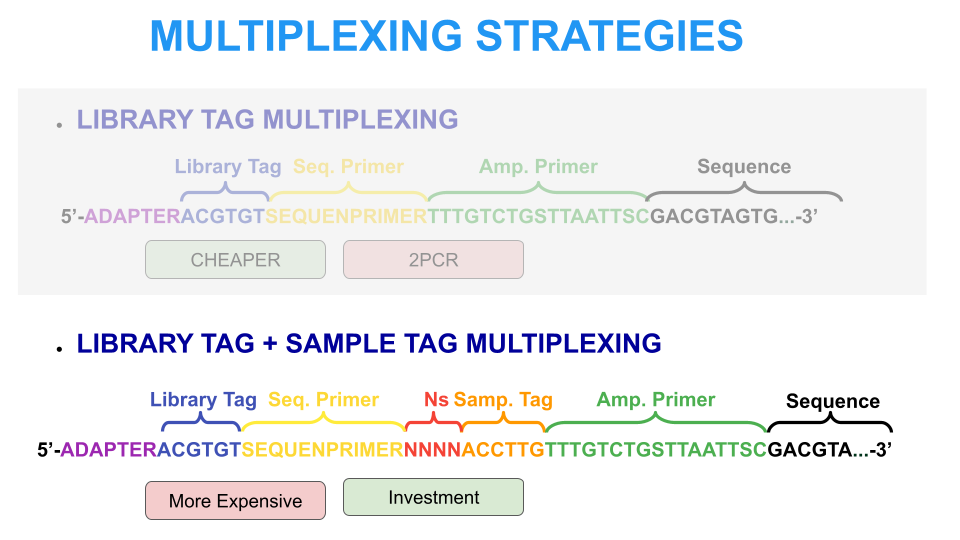

The library tag is used by the sequencer to return different files, one for each Library. However as the sequencer does not identify the sample, tag we have to do it.

## Hands-on
First we need to identify for a certain sample:

1. Initial files (R1 and R2)
2. Sample Name
3. Fwd and Rev sample tag
4. Fwd and Rev primers

We can see them in the metadata files

In [11]:
%%bash
echo ""
echo "Step 2: Demultiplexing and Primer Removal"
echo "Running demultiplexing and primer removal using cutadapt..."
echo "We are going to extract que first sample from the R1 files:"
head -n 2 /content/MetabarcodingCourse/test_one_sample/ULOY_metadata.tsv
# "mjolnir_agnomens"  "original_samples"  "date"        "group"	"position"	"BLANK"
# "ULO1_sample_006"	  "10_25_M1_A_C"	    "2017_10_25"  "cage"	"cage_M1"
echo ""
echo "ngsfile information:"
head -n 1 /content/MetabarcodingCourse/test_one_sample/ngsfilter_ULO1.tsv
# ULO1	ULO1_sample_006	ggatgatc:ggatgatc	GGWACWRGWTGRACWNTNTAYCCYCC	TANACYTCNGGRTGNCCRAARAAYCA
echo ""


Step 2: Demultiplexing and Primer Removal
Running demultiplexing and primer removal using cutadapt...
We are going to extract que first sample from the R1 files:
mjolnir_agnomens	original_samples	date	group	position	BLANK
ULO1_sample_006	10_25_M1_A_C	2017_10_25	cage	cage_M1	

ngsfile information:
ULO1	ULO1_sample_006	ggatgatc:ggatgatc	GGWACWRGWTGRACWNTNTAYCCYCC	TANACYTCNGGRTGNCCRAARAAYCA



We then prepare fasta files for the parts of the sequence that cutadapt will search for:

sample tags and primers


In [12]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/

SAMPLE_NAME="ULO1_sample_006"
FWD_tag="ggatgatc"
REV_tag="ggatgatc"

echo -e ">${SAMPLE_NAME}_sametag\n${FWD_tag}" >fwd_tag.fasta
echo -e ">${SAMPLE_NAME}_sametag\n${REV_tag}" >rev_tag.fasta

FWD_PRIMER="GGWACWRGWTGRACWNTNTAYCCYCC"
REV_PRIMER="TANACYTCNGGRTGNCCRAARAAYCA"


echo -e ">${SAMPLE_NAME}_fwd_rev\n${FWD_PRIMER}\n>${SAMPLE_NAME}_rev_fwd\n${REV_PRIMER}" >R1_primers.fasta
echo -e ">${SAMPLE_NAME}_fwd_rev\n${REV_PRIMER}\n>${SAMPLE_NAME}_rev_fwd\n${FWD_PRIMER}" >R2_primers.fasta


## Ex. 2
Check created files.

## A) First cutadapt - search for sample tags

For each sample, cutadapt will search for the sample tag for both R1 and R2 sequences. The first sequence in R1 and R2 are complementary and so on. This means that only if both sample tags are found in the same line for both files (R1 and R2) the sequence will be selected. Otherwise is discarded.

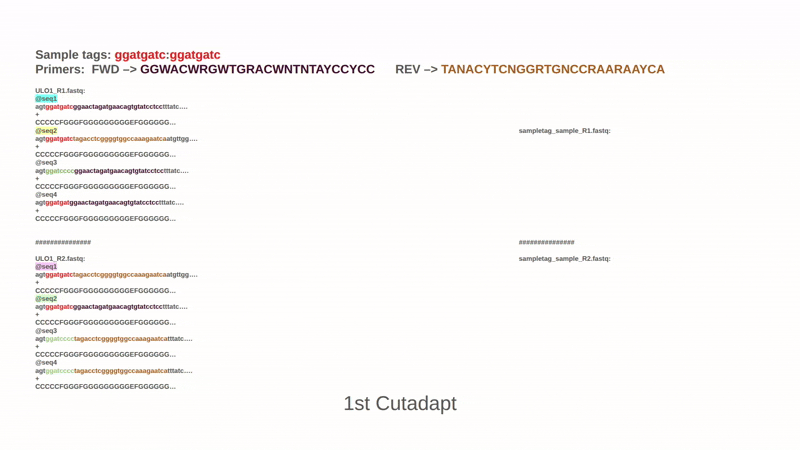

In [13]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/
# variables for the demultiplexing step
# For one sample
R1_FILES="ULO1_R1.fastq.gz"
R2_FILES="ULO1_R2.fastq.gz"
CORES=5

# First we demultiplex the sample tags using cutadapt
cutadapt -e 0 -O 8 --no-indels -j $CORES --action='none' --max-n=0.5 \
    --pair-adapters -g file:fwd_tag.fasta -G file:rev_tag.fasta \
    -o {name}_R1.fastq -p {name}_R2.fastq \
    $R1_FILES $R2_FILES
    # allow 0 errors
    # min 8 overlap required
    # no indels allowed
    # number $CORES of cores allowed
    # don't remove the tag taken
    # save those reads that have not been assigned to the sample
    # save those reads that have not been assigned to the sample
    # I allow a max of half of the read being N. this will be solved in following steps

This is cutadapt 5.2 with Python 3.11.14
Command line parameters: -e 0 -O 8 --no-indels -j 5 --action=none --max-n=0.5 --pair-adapters -g file:fwd_tag.fasta -G file:rev_tag.fasta -o {name}_R1.fastq -p {name}_R2.fastq ULO1_R1.fastq.gz ULO1_R2.fastq.gz
Processing paired-end reads on 5 cores ...

=== Summary ===

Total read pairs processed:             25,658
  Read 1 with adapter:                     167 (0.7%)
  Read 2 with adapter:                     167 (0.7%)

== Read fate breakdown ==
Pairs with too many N:                      80 (0.3%)
Pairs discarded as untrimmed:                0 (0.0%)
Pairs written (passing filters):        25,578 (99.7%)

Total basepairs processed:    12,658,037 bp
  Read 1:     6,328,338 bp
  Read 2:     6,329,699 bp
Total written (filtered):     12,620,414 bp (99.7%)
  Read 1:     6,309,640 bp
  Read 2:     6,310,774 bp

=== First read: Adapter ULO1_sample_006_sametag ===

Sequence: GGATGATC; Type: regular 5'; Length: 8; Trimmed: 167 times

Minimum overlap

## B) Second cutadapt - search for primer sequences

However, if both tags are the same, we need to separate the forward sequences from the reverse ones. This is done also with cutadapt but for each combination of primers.

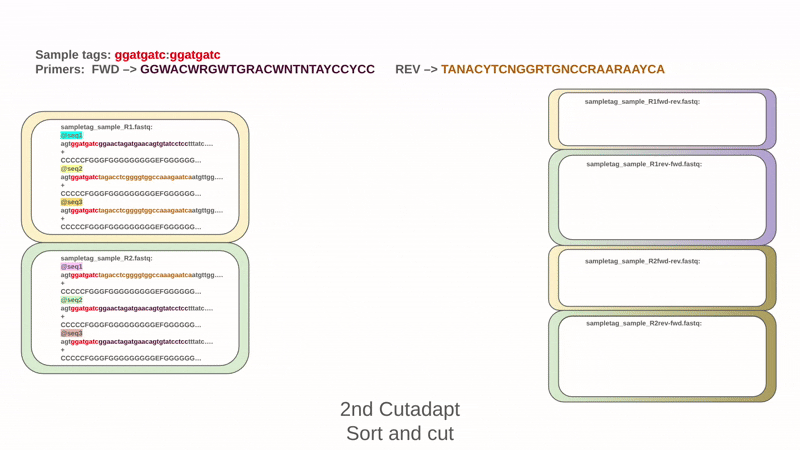

In [14]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/
# variables for the demultiplexing step
# For one sample
CORES=5
SAMPLE_NAME="ULO1_sample_006"


# Then we remove the primers from the demultiplexed files
cutadapt -e 0.1 --no-indels -j $CORES --action='trim' --max-n=0.5 \
    --pair-adapters -g file:R1_primers.fasta -G file:R2_primers.fasta \
    -o {name}_R1.fastq -p {name}_R2.fastq \
    "${SAMPLE_NAME}_sametag_R1.fastq" "${SAMPLE_NAME}_sametag_R2.fastq"
    # allow 10% errors
    # no indels allowed
    # number $CORES of cores allowed
    # remove the primers


This is cutadapt 5.2 with Python 3.11.14
Command line parameters: -e 0.1 --no-indels -j 5 --action=trim --max-n=0.5 --pair-adapters -g file:R1_primers.fasta -G file:R2_primers.fasta -o {name}_R1.fastq -p {name}_R2.fastq ULO1_sample_006_sametag_R1.fastq ULO1_sample_006_sametag_R2.fastq
Processing paired-end reads on 5 cores ...

=== Summary ===

Total read pairs processed:                167
  Read 1 with adapter:                     163 (97.6%)
  Read 2 with adapter:                     163 (97.6%)

== Read fate breakdown ==
Pairs with too many N:                       0 (0.0%)
Pairs discarded as untrimmed:                0 (0.0%)
Pairs written (passing filters):           167 (100.0%)

Total basepairs processed:        83,193 bp
  Read 1:        41,594 bp
  Read 2:        41,599 bp
Total written (filtered):         71,155 bp (85.5%)
  Read 1:        35,581 bp
  Read 2:        35,574 bp

=== First read: Adapter ULO1_sample_006_fwd_rev ===

Sequence: GGWACWRGWTGRACWNTNTAYCCYCC; Type: re

## C) Concatenate output files

Finally, as multiple files have been created, they need to be merged to the finals:

***Sample_FWD.fastq*** and ***Sample_REV.fastq***

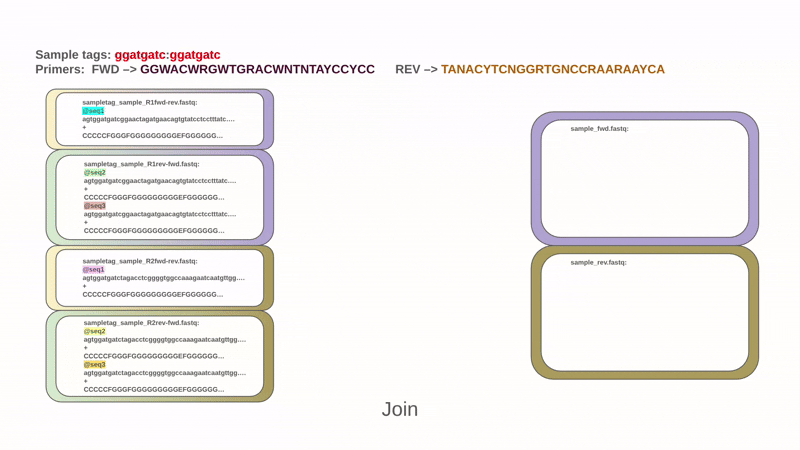

In [15]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/

ORIGINAL_SAMPLE_NAME="10_25_M1_A_C"
SAMPLE_NAME="ULO1_sample_006"

cat ${SAMPLE_NAME}_fwd_rev_R1.fastq \
    ${SAMPLE_NAME}_rev_fwd_R2.fastq > ${ORIGINAL_SAMPLE_NAME}_R1.fastq

cat ${SAMPLE_NAME}_fwd_rev_R2.fastq \
    ${SAMPLE_NAME}_rev_fwd_R1.fastq > ${ORIGINAL_SAMPLE_NAME}_R2.fastq

rm ${SAMPLE_NAME}_fwd_rev_R*.fastq ${SAMPLE_NAME}_rev_fwd_R*.fastq \
    ${SAMPLE_NAME}_sametag_R*.fastq unknown*_R*.fastq

## Ex. 3
Do the Demultiplexing for the sample:

ULO1_sample_018

### Ex. 3.0 Get variables information

R1 Initial File: ULO1_R1.fastq.gz

R2 Initial File: ULO1_R2.fastq.gz

Sample name: ULO1_sample_018

Original Sample name: [...]

Fwd tag: [...]

Rev tag: [...]

Fwd Primer: GGWACWRGWTGRACWNTNTAYCCYCC

Rev Primer: TANACYTCNGGRTGNCCRAARAAYCA

### Ex. 3.1 Create fasta files for sample tags and primers

We then prepare fasta files for the parts of the sequence that cutadapt will search for:

sample tags and primers


In [20]:
We then prepare fasta files for the parts of the sequence that cutadapt will search for:

sample tags and primers
```bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/

SAMPLE_NAME="ULO1_sample_018"
# ToDo
FWD_tag="ggatgatc"
REV_tag="ggatgatc"

echo -e ">${SAMPLE_NAME}_sametag\n${FWD_tag}" >fwd_tag.fasta
echo -e ">${SAMPLE_NAME}_sametag\n${REV_tag}" >rev_tag.fasta

FWD_PRIMER="GGWACWRGWTGRACWNTNTAYCCYCC"
REV_PRIMER="TANACYTCNGGRTGNCCRAARAAYCA"


echo -e ">${SAMPLE_NAME}_fwd_rev\n${FWD_PRIMER}\n>${SAMPLE_NAME}_rev_fwd\n${REV_PRIMER}" >R1_primers.fasta
echo -e ">${SAMPLE_NAME}_fwd_rev\n${REV_PRIMER}\n>${SAMPLE_NAME}_rev_fwd\n${FWD_PRIMER}" >R2_primers.fasta
```

SyntaxError: invalid syntax (1289314454.py, line 1)

### Ex. 3.2 A) First Cutadapt

In [18]:
### Ex. 3.2 A) First Cutadapt

```bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/
# variables for the demultiplexing step
# For one sample

# ToDo
R1_FILES="ULO1_R1.fastq.gz"
R2_FILES="ULO1_R2.fastq.gz"
CORES=5

# First we demultiplex the sample tags using cutadapt
cutadapt -e 0 -O 8 --no-indels -j $CORES --action='none' --max-n=0.5 \
    --pair-adapters -g file:fwd_tag.fasta -G file:rev_tag.fasta \
    -o {name}_R1.fastq -p {name}_R2.fastq \
    $R1_FILES $R2_FILES
    # allow 0 errors
    # min 8 overlap required
    # no indels allowed
    # number $CORES of cores allowed
    # don't remove the tag taken
    # save those reads that have not been assigned to the sample
    # save those reads that have not been assigned to the sample
    # I allow a max of half of the read being N. this will be solved in following steps
```

This is cutadapt 5.2 with Python 3.11.14
Command line parameters: -e 0 -O 8 --no-indels -j 5 --action=none --max-n=0.5 --pair-adapters -g file:fwd_tag.fasta -G file:rev_tag.fasta -o {name}_R1.fastq -p {name}_R2.fastq [...] [...]


Character '[' in adapter sequence '[' is not a valid IUPAC code. Use only characters 'ABCDGHIKMNRSTUVWXY'.


CalledProcessError: Command 'b"source /usr/local/etc/profile.d/conda.sh\nconda activate metabarcoding\n\ncd /content/MetabarcodingCourse/test_one_sample/\n# variables for the demultiplexing step\n# For one sample\n\n# ToDo\nR1_FILES=[...]\nR2_FILES=[...]\nCORES=5\n\n# First we demultiplex the sample tags using cutadapt\ncutadapt -e 0 -O 8 --no-indels -j $CORES --action='none' --max-n=0.5 \\\n    --pair-adapters -g file:fwd_tag.fasta -G file:rev_tag.fasta \\\n    -o {name}_R1.fastq -p {name}_R2.fastq \\\n    $R1_FILES $R2_FILES\n    # allow 0 errors\n    # min 8 overlap required\n    # no indels allowed\n    # number $CORES of cores allowed\n    # don't remove the tag taken\n    # save those reads that have not been assigned to the sample\n    # save those reads that have not been assigned to the sample\n    # I allow a max of half of the read being N. this will be solved in following steps\n"' returned non-zero exit status 2.

### Ex. 3.3 B) Second Cutadapt

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/
# variables for the demultiplexing step
# For one sample
CORES=5
SAMPLE_NAME="ULO1_sample_018"


# Then we remove the primers from the demultiplexed files

# ToDo
cutadapt -e 0.1 --no-indels -j $CORES [...]
    # allow 10% errors
    # no indels allowed
    # number $CORES of cores allowed
    # remove the primers


This is cutadapt 5.2 with Python 3.11.14
Command line parameters: -e 0.1 --no-indels -j 5 --action=trim --max-n=0.5 --pair-adapters -g file:R1_primers.fasta -G file:R2_primers.fasta -o {name}_R1.fastq -p {name}_R2.fastq ULO1_sample_006_sametag_R1.fastq ULO1_sample_006_sametag_R2.fastq
Processing paired-end reads on 5 cores ...

=== Summary ===

Total read pairs processed:                167
  Read 1 with adapter:                     163 (97.6%)
  Read 2 with adapter:                     163 (97.6%)

== Read fate breakdown ==
Pairs with too many N:                       0 (0.0%)
Pairs discarded as untrimmed:                0 (0.0%)
Pairs written (passing filters):           167 (100.0%)

Total basepairs processed:        83,193 bp
  Read 1:        41,594 bp
  Read 2:        41,599 bp
Total written (filtered):         71,155 bp (85.5%)
  Read 1:        35,581 bp
  Read 2:        35,574 bp

=== First read: Adapter ULO1_sample_006_fwd_rev ===

Sequence: GGWACWRGWTGRACWNTNTAYCCYCC; Type: re

### Ex. 3.4 C) Concatenate output files

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/

ORIGINAL_SAMPLE_NAME=[...]
SAMPLE_NAME="ULO1_sample_018"

cat ${SAMPLE_NAME}_fwd_rev_R1.fastq \
    ${SAMPLE_NAME}_rev_fwd_R2.fastq > ${ORIGINAL_SAMPLE_NAME}_R1.fastq

# ToDo
cat [...]
# ToDo
rm [...]

# 3 - Merging Paired-End Reads

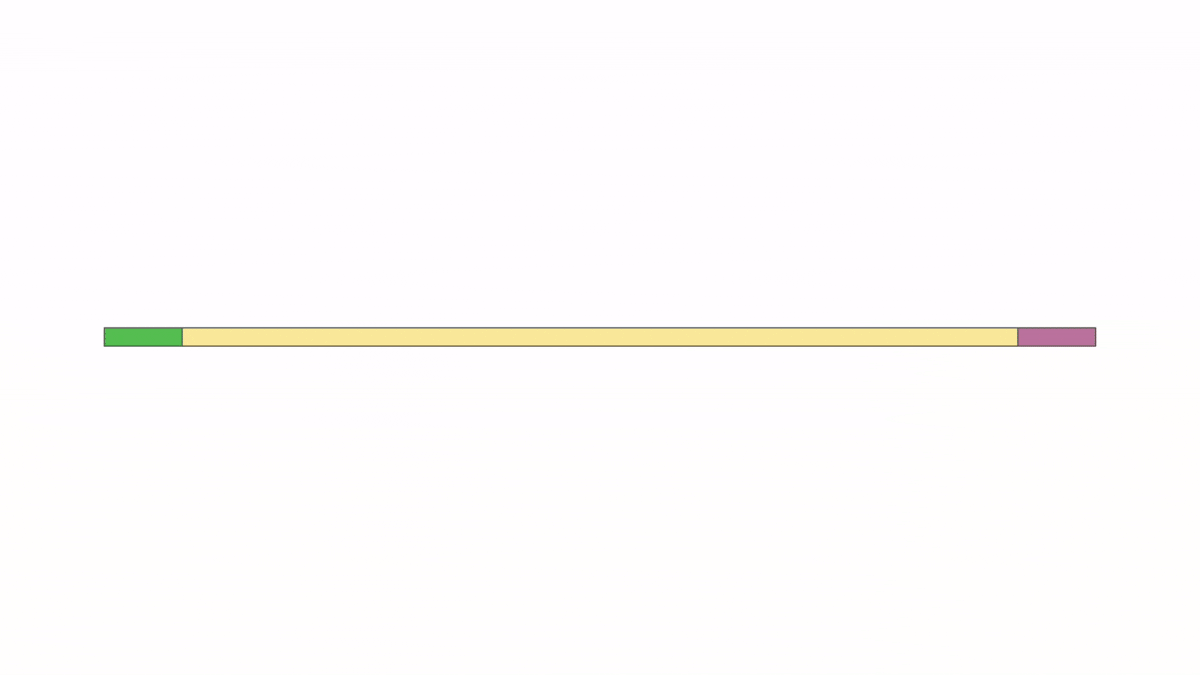

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/

echo "Step 3: Merging Paired-End Reads"
echo "Merging forward and reverse reads..."


LIB_PREFIX="ULO1"
EXPERIMENT="ULOY"
CORES=5
ORIGINAL_SAMPLE_NAME="10_25_M1_A_C"
SAMPLE_NAME="ULO1_sample_006"

vsearch --fastq_mergepairs "${ORIGINAL_SAMPLE_NAME}_R1.fastq" \
    --reverse "${ORIGINAL_SAMPLE_NAME}_R2.fastq" \
    --fastqout "${EXPERIMENT}_${SAMPLE_NAME}_aligned.fastq" \
    --fastq_minovlen 40 \
    --fastq_maxdiffs 20 \
    --fastq_maxee 1 \
    --fastq_minmergelen 299 \
    --fastq_maxmergelen 320 \
    --fastq_maxns 0
    # merge pairs of sequences
    # min overlap of 40 bp
    # no differences allowed in the overlap
    # max expected errors of 0.5
    # min merged length of 299 bp
    # max merged length of 320 bp
    # max number of Ns allowed is 0

Step 3: Merging Paired-End Reads
Merging forward and reverse reads...


vsearch v2.30.1_linux_x86_64, 12.7GB RAM, 2 cores
https://github.com/torognes/vsearch

Merging reads 100%
       163  Pairs
       141  Merged (86.5%)
        22  Not merged (13.5%)

Pairs that failed merging due to various reasons:
         7  expected error too high
         1  merged fragment too short
        11  merged fragment too long
         3  staggered read pairs

Statistics of all reads:
    212.12  Mean read length

Statistics of merged reads:
    312.04  Mean fragment length
      3.15  Standard deviation of fragment length
      0.18  Mean expected error in forward sequences
      0.21  Mean expected error in reverse sequences
      0.10  Mean expected error in merged sequences
      0.17  Mean observed errors in merged region of forward sequences
      0.20  Mean observed errors in merged region of reverse sequences
      0.37  Mean observed errors in merged region


# 4 - Dereplication

PCR, although it may produce errors, is quite precice on replicating DNA sequences. This means that in our files we have a redundancy of information. Each sequence is repeated exactly many times. In order to reduce the size of the files, we will keep one exact copy for each replicated sequence and keep how many copies of that sequence we had.

## Ex. 4
Perform the dereplication of the ULO1_sample_006 processed in previous steps.

Hints:
1. We use vsearch
2. We need to specify three parameters
3. The parameters call for: "Do dereplication"; "Get the size of each amplicon (number of sequences merged)"; "The output file must be in fasta format"

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/


EXPERIMENT="ULOY"
SAMPLE_NAME="ULO1_sample_006"

# ToDo
vsearch --[...] "${EXPERIMENT}_${SAMPLE_NAME}_aligned.fastq" \
    --[...] \
    --[...] "${EXPERIMENT}_${SAMPLE_NAME}_uniq.fasta"

Step 3: Merging Paired-End Reads
Merging forward and reverse reads...


vsearch v2.30.1_linux_x86_64, 12.7GB RAM, 2 cores
https://github.com/torognes/vsearch

Merging reads 100%
       163  Pairs
       141  Merged (86.5%)
        22  Not merged (13.5%)

Pairs that failed merging due to various reasons:
         7  expected error too high
         1  merged fragment too short
        11  merged fragment too long
         3  staggered read pairs

Statistics of all reads:
    212.12  Mean read length

Statistics of merged reads:
    312.04  Mean fragment length
      3.15  Standard deviation of fragment length
      0.18  Mean expected error in forward sequences
      0.21  Mean expected error in reverse sequences
      0.10  Mean expected error in merged sequences
      0.17  Mean observed errors in merged region of forward sequences
      0.20  Mean observed errors in merged region of reverse sequences
      0.37  Mean observed errors in merged region


In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda activate metabarcoding

cd /content/MetabarcodingCourse/test_one_sample/


EXPERIMENT="ULOY"
SAMPLE_NAME="ULO1_sample_006"


# ToDo
vsearch [...] \
    [...] \
    [...] "${EXPERIMENT}_${SAMPLE_NAME}_uniq.fasta"

Step 3: Merging Paired-End Reads
Merging forward and reverse reads...


vsearch v2.30.1_linux_x86_64, 12.7GB RAM, 2 cores
https://github.com/torognes/vsearch

Merging reads 100%
       163  Pairs
       141  Merged (86.5%)
        22  Not merged (13.5%)

Pairs that failed merging due to various reasons:
         7  expected error too high
         1  merged fragment too short
        11  merged fragment too long
         3  staggered read pairs

Statistics of all reads:
    212.12  Mean read length

Statistics of merged reads:
    312.04  Mean fragment length
      3.15  Standard deviation of fragment length
      0.18  Mean expected error in forward sequences
      0.21  Mean expected error in reverse sequences
      0.10  Mean expected error in merged sequences
      0.17  Mean observed errors in merged region of forward sequences
      0.20  Mean observed errors in merged region of reverse sequences
      0.37  Mean observed errors in merged region


##Ex. 5
Why do we need the output to be in fasta format and not in fastq?

Answer: ...